<a href="https://colab.research.google.com/github/mahdiyahk/F1-Lap-Analysis/blob/main/og_2025_f1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ANOVA result: F_onewayResult(statistic=np.float64(0.7802244181063259), pvalue=np.float64(0.4597140848343556))
MSE: 3.51, R2: -0.14
Top 5 predicted lap times:
    tire_pressure  tire_temperature  tire_compound_Medium  tire_compound_Soft  \
89             23                90                  True                   0   
65             22                90                  True                   0   
41             21                90                  True                   0   
91             23                90                  True                   0   
17             20                90                  True                   0   

    track_name_Silverstone  weather_condition_Rainy  weather_condition_Sunny  \
89                    True                        0                    False   
65                    True                        0                    False   
41                    True                        0                    False   
91                   False         

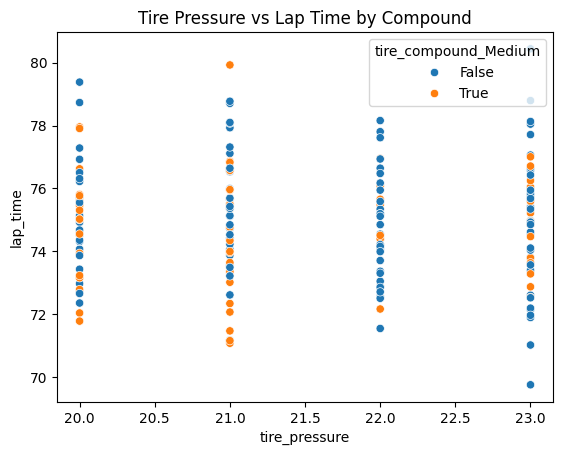

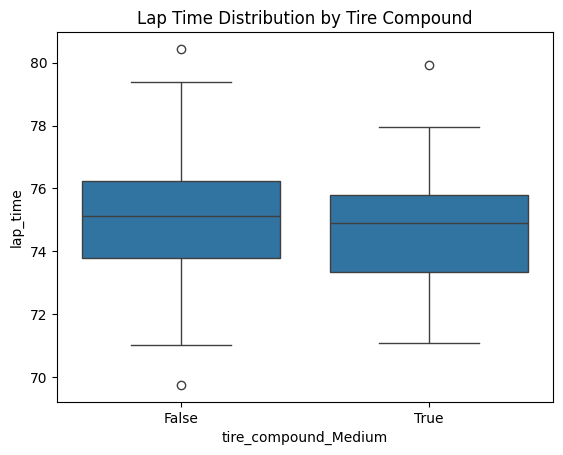

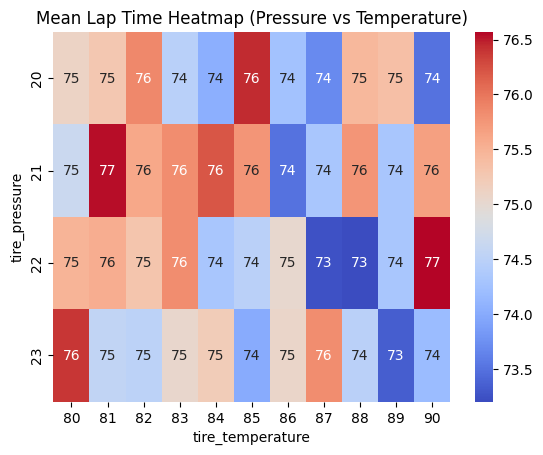

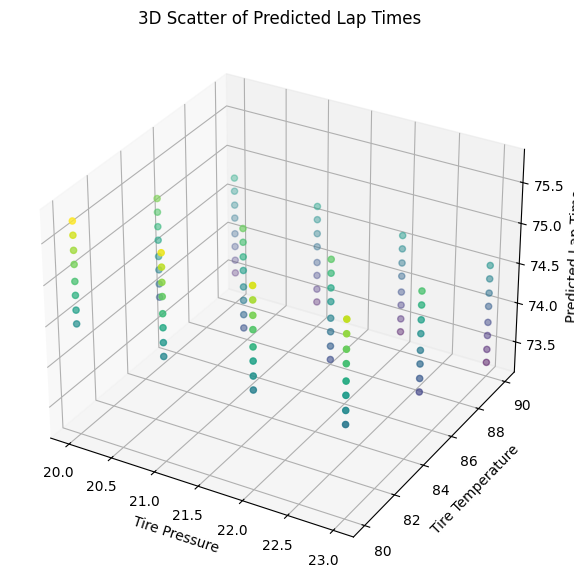

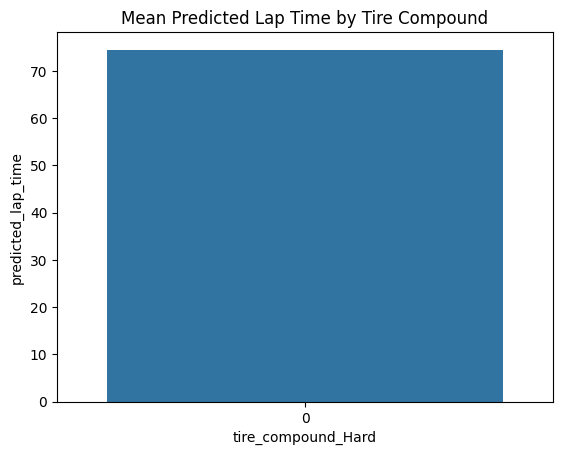

interactive(children=(IntSlider(value=21, description='tire_pressure', max=23, min=20), IntSlider(value=85, de…

<function __main__.predict_lap(tire_pressure, tire_temperature, tire_compound, track_name, weather_condition)>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import f_oneway
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from ipywidgets import interact, IntSlider, Dropdown


# Create synthetic data

np.random.seed(42)

n = 200  # number of rows

data = pd.DataFrame({
    'lap_time': np.random.normal(75, 2, n),  # average lap 75s
    'tire_pressure': np.random.randint(20, 24, n),
    'tire_temperature': np.random.randint(80, 91, n),
    'tire_compound': np.random.choice(['Soft','Medium','Hard'], n),
    'track_name': np.random.choice(['Silverstone','Monza'], n),
    'weather_condition': np.random.choice(['Sunny','Cloudy','Rainy'], n)
})

# Optional: save to CSV
# data.to_csv("f1_data.csv", index=False)


# Hypothesis testing

compounds = data['tire_compound'].unique()

if len(compounds) > 1:
    anova = f_oneway(
        *(data[data['tire_compound'] == c]['lap_time'] for c in compounds)
    )
    print(f"ANOVA result: {anova}")


# Encode categorical variables

data = pd.get_dummies(
    data,
    columns=['tire_compound', 'track_name', 'weather_condition'],
    drop_first=True
)

expected_cols = [
    'tire_pressure',
    'tire_temperature',
    'tire_compound_Medium',
    'tire_compound_Hard',
    'track_name_Monza',
    'weather_condition_Rainy',
    'weather_condition_Sunny'
]

for col in expected_cols:
    if col not in data.columns:
        data[col] = 0


# Features and target

X = data.drop('lap_time', axis=1)
y = data['lap_time']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# Train model

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(
    f"MSE: {mean_squared_error(y_test, y_pred):.2f}, "
    f"R2: {r2_score(y_test, y_pred):.2f}"
)


# Simulation

pressures = [20, 21, 22, 23]
temperatures = [80, 85, 90]
compounds = ['Medium', 'Hard']
tracks = ['Silverstone', 'Monza']
weathers = ['Sunny', 'Rainy']

combinations = list(
    itertools.product(
        pressures,
        temperatures,
        compounds,
        tracks,
        weathers
    )
)

sim_df = pd.DataFrame(
    combinations,
    columns=[
        'tire_pressure',
        'tire_temperature',
        'tire_compound',
        'track_name',
        'weather_condition'
    ]
)

sim_df = pd.get_dummies(
    sim_df,
    columns=['tire_compound', 'track_name', 'weather_condition'],
    drop_first=True
)

for col in X_train.columns:
    if col not in sim_df.columns:
        sim_df[col] = 0

sim_df = sim_df[X_train.columns]

# Predict lap times

sim_df['predicted_lap_time'] = model.predict(sim_df)
sim_df = sim_df.sort_values('predicted_lap_time')

print("Top 5 predicted lap times:")
print(sim_df.head())


# Visualisations

# Tire pressure vs lap time

sns.scatterplot(
    x='tire_pressure',
    y='lap_time',
    hue='tire_compound_Medium',
    data=data
)

plt.title("Tire Pressure vs Lap Time by Compound")
plt.show()


# Lap time distribution by compound

sns.boxplot(
    x='tire_compound_Medium',
    y='lap_time',
    data=data
)

plt.title("Lap Time Distribution by Tire Compound")
plt.show()


# Mean lap time for different pressure/temperature combinations

pivot_table = data.pivot_table(
    values='lap_time',
    index='tire_pressure',
    columns='tire_temperature',
    aggfunc='mean'
)

sns.heatmap(pivot_table, annot=True, cmap='coolwarm')

plt.title("Mean Lap Time Heatmap (Pressure vs Temperature)")
plt.show()


# 3D scatter plot of predicted lap times

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    sim_df['tire_pressure'],
    sim_df['tire_temperature'],
    sim_df['predicted_lap_time'],
    c=sim_df['predicted_lap_time'],
    cmap='viridis'
)

ax.set_xlabel('Tire Pressure')
ax.set_ylabel('Tire Temperature')
ax.set_zlabel('Predicted Lap Time')

plt.title("3D Scatter of Predicted Lap Times")
plt.show()


# Mean predicted lap time by tire compound

mean_compound = (
    sim_df.groupby('tire_compound_Hard')['predicted_lap_time']
    .mean()
    .reset_index()
)

sns.barplot(
    x='tire_compound_Hard',
    y='predicted_lap_time',
    data=mean_compound
)

plt.title("Mean Predicted Lap Time by Tire Compound")
plt.show()


# Interactive dashboard

def predict_lap(
    tire_pressure,
    tire_temperature,
    tire_compound,
    track_name,
    weather_condition
):

    sim = pd.DataFrame({
        'tire_pressure': [tire_pressure],
        'tire_temperature': [tire_temperature],
        'tire_compound_Hard': [1 if tire_compound == 'Hard' else 0],
        'tire_compound_Medium': [1 if tire_compound == 'Medium' else 0],
        'track_name_Monza': [1 if track_name == 'Monza' else 0],
        'weather_condition_Rainy': [
            1 if weather_condition == 'Rainy' else 0
        ],
        'weather_condition_Sunny': [
            1 if weather_condition == 'Sunny' else 0
        ]
    })

    for col in X_train.columns:
        if col not in sim.columns:
            sim[col] = 0

    sim = sim[X_train.columns]

    predicted = model.predict(sim)[0]

    print(f"Predicted Lap Time: {predicted:.2f} seconds")


    # Heatmap for pressure vs temperature

    pressures = np.arange(20, 24)
    temperatures = np.arange(80, 91, 5)

    mesh, times = [], []

    for p in pressures:
        for t in temperatures:

            row = pd.DataFrame({
                'tire_pressure': [p],
                'tire_temperature': [t],
                'tire_compound_Hard': [
                    1 if tire_compound == 'Hard' else 0
                ],
                'tire_compound_Medium': [
                    1 if tire_compound == 'Medium' else 0
                ],
                'track_name_Monza': [
                    1 if track_name == 'Monza' else 0
                ],
                'weather_condition_Rainy': [
                    1 if weather_condition == 'Rainy' else 0
                ],
                'weather_condition_Sunny': [
                    1 if weather_condition == 'Sunny' else 0
                ]
            })

            for col in X_train.columns:
                if col not in row.columns:
                    row[col] = 0

            row = row[X_train.columns]

            mesh.append((p, t))
            times.append(model.predict(row)[0])

    heatmap_data = pd.DataFrame(
        mesh,
        columns=['Pressure', 'Temperature']
    )

    heatmap_data['LapTime'] = times

    pivot = heatmap_data.pivot(
        index="Pressure",
        columns="Temperature",
        values="LapTime"
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )

    plt.title(
        f"Predicted Lap Times - {tire_compound}, "
        f"{track_name}, {weather_condition}"
    )

    plt.show()


# Interactive sliders and dropdowns

interact(
    predict_lap,
    tire_pressure=IntSlider(
        min=20,
        max=23,
        step=1,
        value=21
    ),
    tire_temperature=IntSlider(
        min=80,
        max=90,
        step=1,
        value=85
    ),
    tire_compound=Dropdown(
        options=['Soft', 'Medium', 'Hard']
    ),
    track_name=Dropdown(
        options=['Silverstone', 'Monza']
    ),
    weather_condition=Dropdown(
        options=['Sunny', 'Cloudy', 'Rainy']
    )
)